#### Задание 1. 
Эмпирическим методом оценить временную сложность алгоритма поиска двух максимальных чисел в массиве, заполненном случайными целыми числами.

1.1 Доказать аналитическим образом существование решения задачи. \
1.2 Разработать несколько вариантов программы (функции) для поиска двух максимальных чисел в одномерном целочисленном массиве А [n]. Провести тестирование работы программы на массиве, введённом с клавиатуры, а также на массиве, сгенерированном с помощью генератора случайных чисел. Оценить скорость работы алгоритма на убывающей и возрастающей последовательности. \
1.3 Выполнить контрольные прогоны программы для размеров массива: п = 100 , 1000, 10000, 100000, 1000000 элементов, измерив время выполнения Т(n) (в секундах). Результаты занести в сводную таблицу. \
1.4 Построить график зависимости времени выполнения алгоритма от размера массива. \
1.5 Обеспечить подсчет фактического количества операций сравнения Сф и присваивания Мф. Результаты Сф + Мф включить в сводную таблицу. \
1.6 Проанализировать результаты. Сделать выводы о работе алгоритма. 

2 максимальных числа в произвольном массиве \
2 - 3 алгоритма, также проверить скорость на убывающем и возрастающем массиве

In [43]:
import datetime

#A = [1, 3, 6, 8, 91]
#A = [91, 3, 6, 8, 1]

#### 1 алг

In [46]:
#A = [1, 3, 6, 8, 91]
A = [91, 3, 6, 8, 1]

def max_user(ar):
    start = datetime.datetime.now()

    max1, max2 = ar[:2]
    
    for i in range(2, len(ar)):
        num = ar[i]
        
        if num > max1:
            max2 = max1
            max1 = num

        elif num > max2:
            max2 = num

    finish = datetime.datetime.now()

    print(max1, max2)
    print(f'Время работы: {finish - start}')

max_user(A)

91 8
Время работы: 0:00:00


#### 2 алг

In [49]:
# 2 алг

A = [1, 3, 6, 8, 91]
#A = [91, 3, 6, 8, 1]

def max_user(ar):
    start = datetime.datetime.now()
    
    ar_sorted = sorted(ar) 
    max1 = ar_sorted[-1]
    max2 = ar_sorted[-2]

    finish = datetime.datetime.now()
    
    print(max1, max2)
    print(f'Время работы: {finish - start}')

max_user(A)

91 8
Время работы: 0:00:00


#### 3 алг

In [52]:
# ПРИМЕР

arr = [3, 7, 2, 9, 5, 1, 8, 4]  
nums = []
for num in arr:
    nums.append(num)

print("Начальный список nums:", nums)

for iteration in range(1, 3):  # Только 2 итерации
    next_nums = []
    
    i = 0
    while i < len(nums):
        if i + 1 < len(nums):
            a = nums[i]
            b = nums[i + 1]
            
            max_value = ((a + b) + abs(b - a)) // 2
            
            next_nums.append(max_value)
            i += 2
        else:
            next_nums.append(nums[i])
            i += 1
    
    nums = next_nums
    print(f"После итерации {iteration}: nums = {nums}")

print("\nДва максимальных числа:", nums)

Начальный список nums: [3, 7, 2, 9, 5, 1, 8, 4]
После итерации 1: nums = [7, 9, 5, 8]
После итерации 2: nums = [9, 8]

Два максимальных числа: [9, 8]


In [66]:
A = [1, 3, 6, 8, 91]

def max_find(arr):
    compare = 0
    assign = 0

    nums = arr[:]
    assign += len(nums)

    candidates = []

    while len(nums) > 1:
        next_nums = []
        for i in range(0, len(nums), 2):
            if i + 1 < len(nums):
                a = nums[i]
                b = nums[i + 1]
                compare += 1
                if a > b:
                    max_val = a
                    min_val = b
                else:
                    max_val = b
                    min_val = a
                next_nums.append(max_val)
                candidates.append(min_val)
                assign += 2
            else:
                next_nums.append(nums[i])
                assign += 1
        nums = next_nums
        assign += len(next_nums)

    first_max = nums[0]
    assign += 1

    if not candidates:
        second_max = None
    else:
        second_max = candidates[0]
        assign += 1
        for x in candidates[1:]:
            compare += 1
            if x > second_max:
                second_max = x
                assign += 1

    total_ops = compare + assign
    return first_max, second_max, total_ops, compare, assign

max_find(A)

(91, 8, 32, 7, 25)

In [56]:
import random
import time
import matplotlib.pyplot as plt
import pandas as pd

#sizes = [100, 1000, 10000, 100000, 1000000]
sizes = [100, 1000, 10000]

results = {
    'n': sizes,
    'alg1_time': [],
    'alg1_ops': [],
    'alg2_time': [],
    'alg2_ops': [],
    'alg3_time': [],
    'alg3_ops': []
}

In [58]:
for n in sizes:
    A = [random.randint(1, 1000000) for _ in range(n)]

    def alg1(ar):
        start = time.perf_counter()
        compare = 0
        assign = 0
        max1 = ar[0]
        max2 = ar[1]
        assign += 2
        compare += 1
        
        if max1 < max2:
            max1, max2 = max2, max1
            assign += 2
        
        for i in range(2, len(ar)):
            num = ar[i]
            assign += 1
            compare += 1
            if num > max1:
                max2 = max1
                max1 = num
                assign += 2
            else:
                compare += 1
                if num > max2:
                    max2 = num
                    assign += 1
        
        finish = time.perf_counter()
        ops = compare + assign
        t = finish - start
        
        return max1, max2, t, ops

    m1, m2, t1, ops1 = alg1(A)
    results['alg1_time'].append(t1)
    results['alg1_ops'].append(ops1)

    # Сортировка для 2 алгоритма
    def insertion_sort(ar):
        compare = 0
        assign = 0
        a = ar[:]
        assign += len(a)
        for i in range(1, len(a)):
            key = a[i]
            assign += 1
            j = i - 1
            assign += 1
            while j >= 0:
                compare += 1
                if a[j] > key:
                    a[j + 1] = a[j]
                    assign += 1
                    j -= 1
                    assign += 1
                else:
                    break
            a[j + 1] = key
            assign += 1
        return a, compare, assign

    
    def alg2(ar):
        start = time.perf_counter()
        
        ar_sorted, compare, assign = insertion_sort(ar)
        max1 = ar_sorted[-1]
        max2 = ar_sorted[-2]
        
        assign += 2
        finish = time.perf_counter()
        ops = compare + assign
        t = finish - start
        
        return max1, max2, t, ops

    m1, m2, t2, ops2 = alg2(A)
    results['alg2_time'].append(t2)
    results['alg2_ops'].append(ops2)


    def alg3(arr):
        
        start = time.perf_counter()
        compare = 0
        assign = 0
        
        nums = arr[:]
        assign += len(nums)
        candidates = []
        
        while len(nums) > 1:
            next_nums = []
            
            for i in range(0, len(nums), 2):
                if i + 1 < len(nums):
                    a = nums[i]
                    b = nums[i + 1]
                    assign += 2
                    compare += 1
                    if a > b:
                        max_val = a
                        min_val = b
                    else:
                        max_val = b
                        min_val = a
                    assign += 2
                    next_nums.append(max_val)
                    candidates.append(min_val)
                    assign += 2
                else:
                    next_nums.append(nums[i])
                    assign += 1
            
            nums = next_nums
            assign += len(next_nums)
        
        first_max = nums[0]
        assign += 1
        if not candidates:
            second_max = None
        else:
            second_max = candidates[0]
            assign += 1
        
        for x in candidates[1:]:
            compare += 1
            if x > second_max:
                second_max = x
                assign += 1
        ops = compare + assign
        
        finish = time.perf_counter()
        t = finish - start
        
        return first_max, second_max, t, ops

    m1, m2, t3, ops3 = alg3(A)
    results['alg3_time'].append(t3)
    results['alg3_ops'].append(ops3)

In [59]:
# ТАБЛИЦА
df = pd.DataFrame(results)
print(df)

       n  alg1_time  alg1_ops  alg2_time  alg2_ops  alg3_time  alg3_ops
0    100   0.000012       306   0.000459      8902   0.000038      1003
1   1000   0.000136      3012   0.039304    750750   0.000416     10008
2  10000   0.001217     30012   3.928673  74488269   0.003222    100027


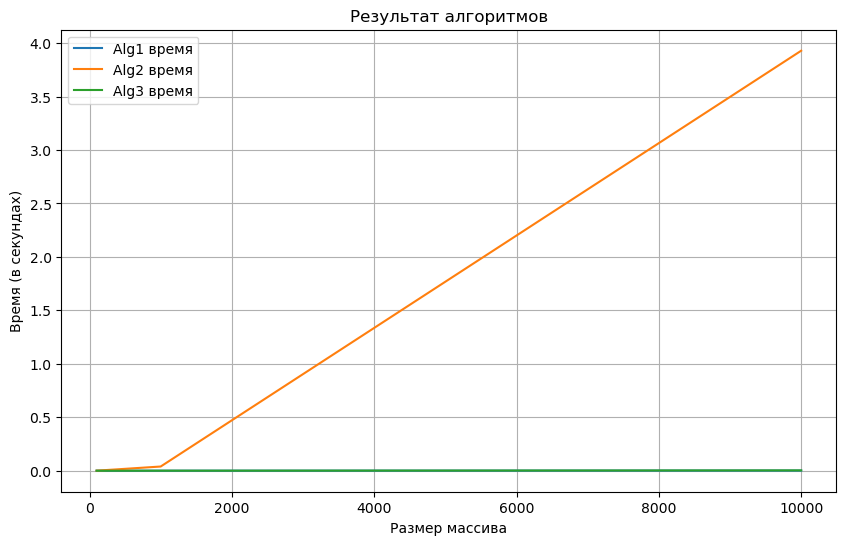

In [60]:
# ГРАФИК
plt.figure(figsize=(10, 6))
plt.plot(df['n'], df['alg1_time'], label='Alg1 время')
plt.plot(df['n'], df['alg2_time'], label='Alg2 время')
plt.plot(df['n'], df['alg3_time'], label='Alg3 время')
plt.xlabel('Размер массива')
plt.ylabel('Время (в секундах)')
plt.title('Результат алгоритмов')
plt.legend()
plt.grid(True)
plt.show()

In [61]:
# ПРОВЕРКА ВРУЧНУЮ
A_keyboard = list(map(int, input("Введите массив вручную через пробел: ").split()))
print("Alg1:", alg1(A_keyboard)[0:2])
print("Alg2:", alg2(A_keyboard)[0:2])
print("Alg3:", alg3(A_keyboard)[0:2])

A_increasing = list(range(1, n_test + 1))

start = time.perf_counter()
alg1(A_increasing)
print("Alg1 increasing time:", time.perf_counter() - start)

start = time.perf_counter()
alg2(A_increasing)
print("Alg2 increasing time:", time.perf_counter() - start)

start = time.perf_counter()
alg3(A_increasing)
print("Alg3 increasing time:", time.perf_counter() - start)

Введите массив вручную через пробел:  10 42 340 342 2592 


Alg1: (2592, 342)
Alg2: (2592, 342)
Alg3: (2592, 342)
Alg1 increasing time: 0.0014315000153146684
Alg2 increasing time: 0.002407200023299083
Alg3 increasing time: 0.0039032000058796257
